In [7]:
# ============================================================
# CELDA 1 — Imports y Constantes
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Intentar importar wordcloud (pip install wordcloud si no está)
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    print("⚠️  WordCloud no instalado. Ejecuta: pip install wordcloud")
    WORDCLOUD_AVAILABLE = False

# ── Paleta de colores (consistente con el EDA existente) ──
COLOR_0   = '#3498db'  # Azul  — No Depresivo
COLOR_1   = '#e74c3c'   # Rojo  — Depresivo
PALETTE   = {0: COLOR_0, 1: COLOR_1}
ALPHA     = 0.80

# ── Estilo global ──
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid':       True,
    'grid.alpha':      0.35,
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi':      120,
})

print("✅ Imports y constantes cargados.")


✅ Imports y constantes cargados.


In [8]:
# ============================================================
# CELDA 2 — Carga de Datos
# ============================================================
# ⚠️ Ajusta el nombre del archivo según tu CSV en data/processed/
DATA_PATH = '../data/raw/dataset_depresion.xlsx'

df = pd.read_excel(DATA_PATH)

# ── Verifica estas columnas; cámbialas si tu CSV usa otros nombres ──
COL_TEXTO = 'text'                  # columna con el texto libre
COL_LABEL = 'manual_classification' # columna binaria (0/1)
COL_NIVEL = 'depression_level'      # columna con nivel BDI (1-5)

# Limpieza básica: eliminar nulos en columna de texto
df = df.dropna(subset=[COL_TEXTO]).reset_index(drop=True)
df[COL_TEXTO] = df[COL_TEXTO].astype(str)

# ── Calcular longitud en palabras ──
df['num_palabras'] = df[COL_TEXTO].apply(lambda x: len(x.split()))

print(f"✅ Dataset cargado: {len(df)} registros")
print(f"   Clase 0 (No Depresivo): {(df[COL_LABEL]==0).sum()}")
print(f"   Clase 1 (Depresivo):    {(df[COL_LABEL]==1).sum()}")


✅ Dataset cargado: 1136 registros
   Clase 0 (No Depresivo): 695
   Clase 1 (Depresivo):    441


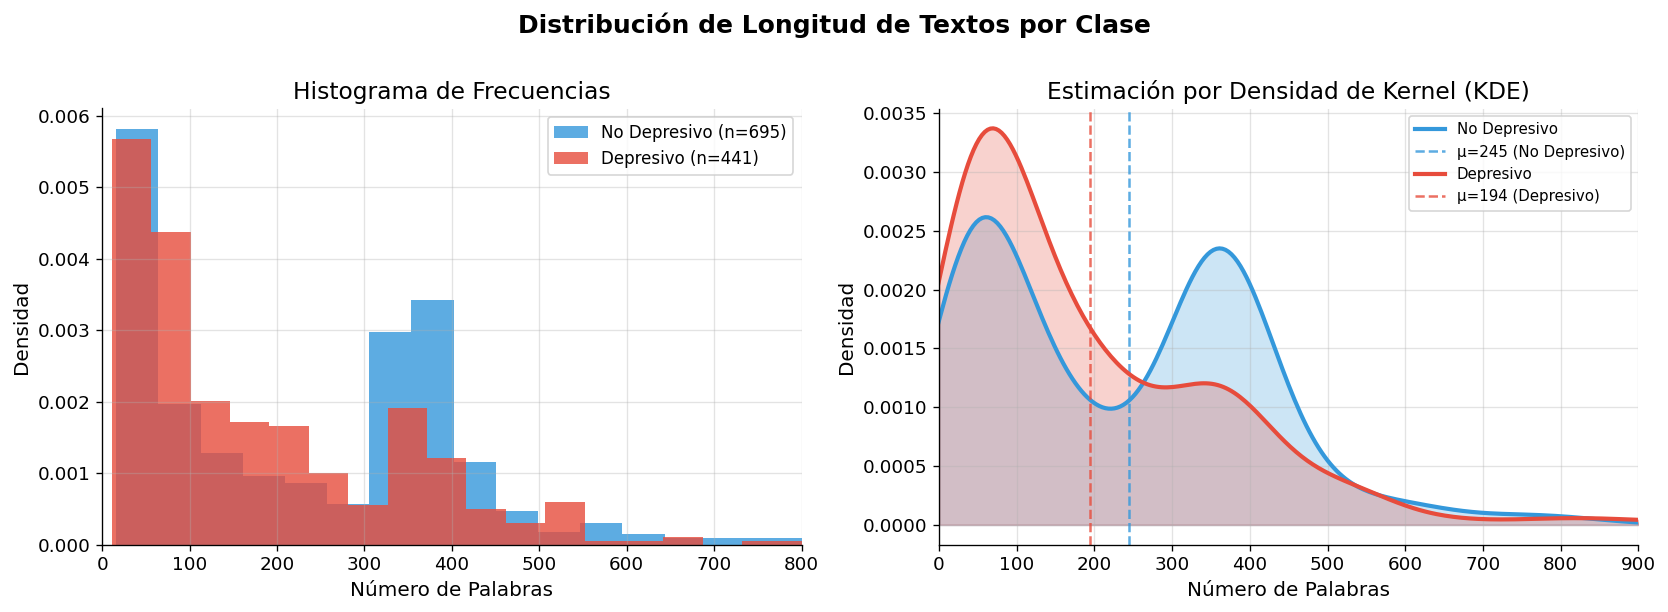

✅ Figura guardada.


In [9]:
# ============================================================
# CELDA 3 — Distribución de Longitud de Textos (Histograma + KDE)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Longitud de Textos por Clase', fontsize=15, fontweight='bold', y=1.01)

etiquetas = {0: 'No Depresivo', 1: 'Depresivo'}

# ── 3a. Histograma superpuesto ──
ax = axes[0]
for label, color in PALETTE.items():
    subset = df[df[COL_LABEL] == label]['num_palabras']
    ax.hist(subset, bins=40, color=color, alpha=ALPHA,
            label=f'{etiquetas[label]} (n={len(subset)})', density=True)
ax.set_xlabel('Número de Palabras')
ax.set_ylabel('Densidad')
ax.set_title('Histograma de Frecuencias')
ax.legend()
ax.set_xlim(0, 800)

# ── 3b. KDE suavizado ──
ax2 = axes[1]
for label, color in PALETTE.items():
    subset = df[df[COL_LABEL] == label]['num_palabras']
    subset.plot.kde(ax=ax2, color=color, linewidth=2.5,
                    label=f'{etiquetas[label]}')
    # Área bajo la curva
    kde = stats.gaussian_kde(subset)
    x_range = np.linspace(0, 900, 500)
    ax2.fill_between(x_range, kde(x_range), alpha=0.25, color=color)
    # Línea vertical de la media
    ax2.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5,
                alpha=0.8, label=f'μ={subset.mean():.0f} ({etiquetas[label]})')
ax2.set_xlabel('Número de Palabras')
ax2.set_ylabel('Densidad')
ax2.set_title('Estimación por Densidad de Kernel (KDE)')
ax2.set_xlim(0, 900)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/eda_longitud_distribucion.png', bbox_inches='tight')
plt.show()
print("✅ Figura guardada.")


  TEST MANN-WHITNEY U — Longitud de Textos por Clase
  Estadístico U:    175240.00
  p-valor:          0.000045
  d de Cohen:       0.2441
-------------------------------------------------------
  ✅ Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (α=0.05)
     Los textos de Clase 0 y Clase 1 difieren en longitud.
  Tamaño del efecto: moderado (|d|=0.2441)


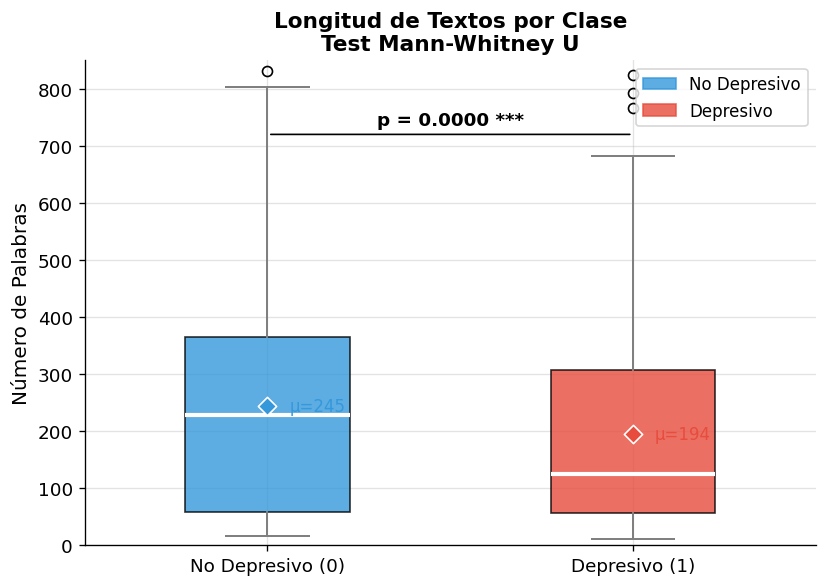

In [11]:
# ============================================================
# CELDA 4 — Test Estadístico: Mann-Whitney U (Longitud por Clase)
# ============================================================
grupo_0 = df[df[COL_LABEL] == 0]['num_palabras']
grupo_1 = df[df[COL_LABEL] == 1]['num_palabras']

stat, p_value = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
cohen_d = (grupo_0.mean() - grupo_1.mean()) / np.sqrt(
    (grupo_0.std()**2 + grupo_1.std()**2) / 2
)

print("=" * 55)
print("  TEST MANN-WHITNEY U — Longitud de Textos por Clase")
print("=" * 55)
print(f"  Estadístico U:    {stat:.2f}")
print(f"  p-valor:          {p_value:.6f}")
print(f"  d de Cohen:       {cohen_d:.4f}")
print("-" * 55)

if p_value < 0.05:
    print(f"  ✅ Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (α=0.05)")
    print(f"     Los textos de Clase 0 y Clase 1 difieren en longitud.")
else:
    print(f"  ❌ Diferencia NO significativa (α=0.05)")

magnitud = "pequeño" if abs(cohen_d) < 0.2 else \
           "moderado" if abs(cohen_d) < 0.5 else "grande"
print(f"  Tamaño del efecto: {magnitud} (|d|={abs(cohen_d):.4f})")
print("=" * 55)

# ── Boxplot comparativo con resultado del test ──
fig, ax = plt.subplots(figsize=(7, 5))
data_plot = [grupo_0.values, grupo_1.values]
bp = ax.boxplot(data_plot, patch_artist=True, widths=0.45,
                medianprops=dict(color='white', linewidth=2.5))

for patch, color in zip(bp['boxes'], [COLOR_0, COLOR_1]):
    patch.set_facecolor(color)
    patch.set_alpha(ALPHA)
for whisker in bp['whiskers']:
    whisker.set(color='gray', linewidth=1.2)
for cap in bp['caps']:
    cap.set(color='gray', linewidth=1.2)

ax.set_xticks([1, 2])
ax.set_xticklabels(['No Depresivo (0)', 'Depresivo (1)'], fontsize=11)
ax.set_ylabel('Número de Palabras')
ax.set_title('Longitud de Textos por Clase\nTest Mann-Whitney U', fontsize=13, fontweight='bold')
ax.set_ylim(0, 850)

# Anotación del p-valor
sigstr = f"p = {p_value:.4f}" + (" ***" if p_value < 0.001 else
                                   " **"  if p_value < 0.01  else
                                   " *"   if p_value < 0.05  else " n.s.")
ax.annotate('', xy=(1, 720), xytext=(2, 720),
            arrowprops=dict(arrowstyle='-', color='black'))
ax.text(1.5, 730, sigstr, ha='center', va='bottom', fontsize=11, fontweight='bold')

# Añadir medias
for i, (grupo, color) in enumerate(zip([grupo_0, grupo_1], [COLOR_0, COLOR_1]), 1):
    ax.scatter(i, grupo.mean(), marker='D', color=color, s=60, zorder=5,
               edgecolors='white', linewidth=1)
    ax.text(i + 0.06, grupo.mean(), f'μ={grupo.mean():.0f}', va='center',
            fontsize=10, color=color)

legend_patches = [mpatches.Patch(color=COLOR_0, alpha=ALPHA, label='No Depresivo'),
                  mpatches.Patch(color=COLOR_1, alpha=ALPHA, label='Depresivo')]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.savefig('../reports/figures/eda_longitud_test_estadistico.png', bbox_inches='tight')
plt.show()


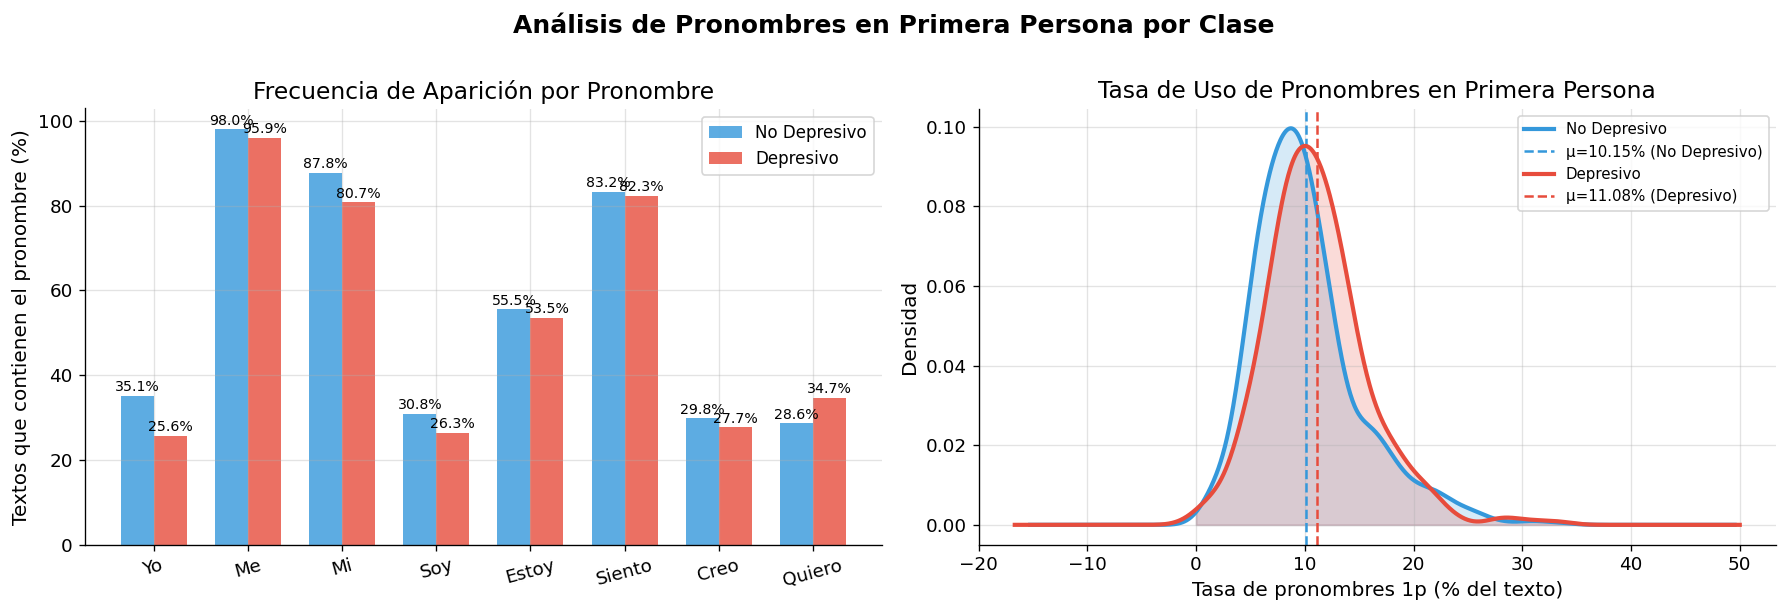


  Pronombres 1p — Mann-Whitney U: stat=129150.50, p=0.000008
  Media Clase 0: 10.154%  |  Media Clase 1: 11.080%


In [12]:
# ============================================================
# CELDA 5 — Análisis de Pronombres en Primera Persona
# ============================================================
# Lista de pronombres en primera persona singular (español)
PRONOMBRES_1P = ['yo', 'me', 'mi', 'mío', 'mía', 'míos', 'mías',
                 'conmigo', 'soy', 'estoy', 'tengo',
                 'siento', 'creo', 'pienso', 'quiero', 'puedo']

def contar_pronombre(texto, pronombre):
    """Cuenta ocurrencias (case-insensitive, palabra completa)."""
    patron = r'\b' + re.escape(pronombre) + r'\b'
    return len(re.findall(patron, texto.lower()))

def tasa_pronombres_1p(texto):
    """Tasa de uso: (total pronombres 1p) / (total palabras)."""
    palabras = texto.split()
    if len(palabras) == 0:
        return 0.0
    total = sum(contar_pronombre(texto, p) for p in PRONOMBRES_1P)
    return (total / len(palabras)) * 100  # en porcentaje

df['tasa_1p'] = df[COL_TEXTO].apply(tasa_pronombres_1p)

# ── Frecuencia de presencia por clase (% de textos que usan el pronombre) ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Análisis de Pronombres en Primera Persona por Clase',
             fontsize=15, fontweight='bold', y=1.01)

# 5a. Frecuencia de presencia por pronombre
pronombres_core = ['yo', 'me', 'mi', 'soy', 'estoy', 'siento', 'creo', 'quiero']
ax = axes[0]
x = np.arange(len(pronombres_core))
ancho = 0.35

for offset, label, color in [(-ancho/2, 0, COLOR_0), (ancho/2, 1, COLOR_1)]:
    subset = df[df[COL_LABEL] == label]
    frecs = [
        (subset[COL_TEXTO].apply(lambda t: contar_pronombre(t, p) > 0).sum()
         / len(subset)) * 100
        for p in pronombres_core
    ]
    bars = ax.bar(x + offset, frecs, ancho, color=color, alpha=ALPHA,
                  label=etiquetas[label])
    for bar, v in zip(bars, frecs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in pronombres_core], rotation=15)
ax.set_ylabel('Textos que contienen el pronombre (%)')
ax.set_title('Frecuencia de Aparición por Pronombre')
ax.legend()

# 5b. Distribución de tasa de uso (pronombres/palabras totales)
ax2 = axes[1]
for label, color in PALETTE.items():
    subset = df[df[COL_LABEL] == label]['tasa_1p']
    subset.plot.kde(ax=ax2, color=color, linewidth=2.5, label=etiquetas[label])
    ax2.fill_between(
        np.linspace(0, subset.max()*1.1, 300),
        stats.gaussian_kde(subset)(np.linspace(0, subset.max()*1.1, 300)),
        alpha=0.20, color=color
    )
    ax2.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5,
                label=f'μ={subset.mean():.2f}% ({etiquetas[label]})')

ax2.set_xlabel('Tasa de pronombres 1p (% del texto)')
ax2.set_ylabel('Densidad')
ax2.set_title('Tasa de Uso de Pronombres en Primera Persona')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/eda_primera_persona.png', bbox_inches='tight')
plt.show()

# ── Test estadístico ──
g0_1p = df[df[COL_LABEL] == 0]['tasa_1p']
g1_1p = df[df[COL_LABEL] == 1]['tasa_1p']
stat_1p, p_1p = stats.mannwhitneyu(g0_1p, g1_1p, alternative='two-sided')
print(f"\n  Pronombres 1p — Mann-Whitney U: stat={stat_1p:.2f}, p={p_1p:.6f}")
print(f"  Media Clase 0: {g0_1p.mean():.3f}%  |  Media Clase 1: {g1_1p.mean():.3f}%")


⏳ Calculando TTR (puede tardar ~30 seg)...
✅ TTR calculado.
  Clase 0 (No Depresivo): μ=0.7372, σ=0.0780
  Clase 1 (Depresivo): μ=0.7407, σ=0.0904

  Mann-Whitney U (TTR): stat=147373.00, p=0.275705


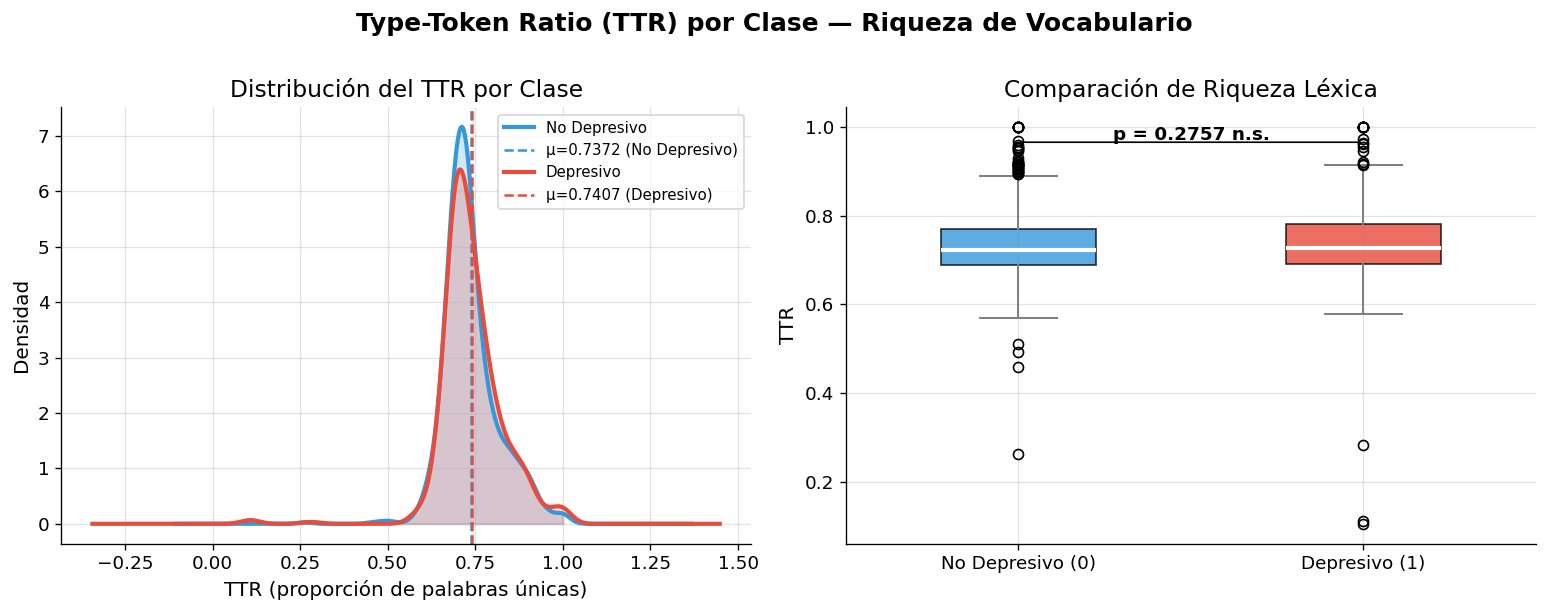

In [13]:
# ============================================================
# CELDA 6 — Type-Token Ratio (TTR) — Riqueza de Vocabulario
# ============================================================
def calcular_ttr(texto, ventana=100):
    """
    TTR estándar: tipos únicos / total tokens.
    Usa ventana deslizante para evitar sesgo por longitud de texto.
    """
    tokens = texto.lower().split()
    if len(tokens) < ventana:
        if len(tokens) == 0:
            return 0.0
        return len(set(tokens)) / len(tokens)
    # Moving Average TTR (MATTR) con ventana de 100 tokens
    ttrs = []
    for i in range(len(tokens) - ventana + 1):
        ventana_tokens = tokens[i:i + ventana]
        ttrs.append(len(set(ventana_tokens)) / ventana)
    return np.mean(ttrs)

print("⏳ Calculando TTR (puede tardar ~30 seg)...")
df['ttr'] = df[COL_TEXTO].apply(calcular_ttr)
print("✅ TTR calculado.")

# ── Estadísticas ──
for label in [0, 1]:
    s = df[df[COL_LABEL] == label]['ttr']
    print(f"  Clase {label} ({etiquetas[label]}): μ={s.mean():.4f}, σ={s.std():.4f}")

stat_ttr, p_ttr = stats.mannwhitneyu(
    df[df[COL_LABEL]==0]['ttr'],
    df[df[COL_LABEL]==1]['ttr'],
    alternative='two-sided'
)
print(f"\n  Mann-Whitney U (TTR): stat={stat_ttr:.2f}, p={p_ttr:.6f}")

# ── Visualización ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Type-Token Ratio (TTR) por Clase — Riqueza de Vocabulario',
             fontsize=15, fontweight='bold', y=1.01)

# 6a. KDE del TTR
ax = axes[0]
for label, color in PALETTE.items():
    subset = df[df[COL_LABEL] == label]['ttr']
    subset.plot.kde(ax=ax, color=color, linewidth=2.5, label=etiquetas[label])
    ax.fill_between(
        np.linspace(subset.min(), subset.max(), 300),
        stats.gaussian_kde(subset)(np.linspace(subset.min(), subset.max(), 300)),
        alpha=0.22, color=color
    )
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5,
               label=f'μ={subset.mean():.4f} ({etiquetas[label]})')
ax.set_xlabel('TTR (proporción de palabras únicas)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución del TTR por Clase')
ax.legend(fontsize=9)

# 6b. Boxplot comparativo
ax2 = axes[1]
data_ttr = [df[df[COL_LABEL]==0]['ttr'].values,
            df[df[COL_LABEL]==1]['ttr'].values]
bp = ax2.boxplot(data_ttr, patch_artist=True, widths=0.45,
                 medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], [COLOR_0, COLOR_1]):
    patch.set_facecolor(color)
    patch.set_alpha(ALPHA)
for w in bp['whiskers']: w.set(color='gray', linewidth=1.2)
for c in bp['caps']:     c.set(color='gray', linewidth=1.2)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(['No Depresivo (0)', 'Depresivo (1)'], fontsize=11)
ax2.set_ylabel('TTR')
ax2.set_title('Comparación de Riqueza Léxica')
sigstr_ttr = f"p = {p_ttr:.4f}" + (" ***" if p_ttr < 0.001 else
                                      " **"  if p_ttr < 0.01  else
                                      " *"   if p_ttr < 0.05  else " n.s.")
ymax = max(df['ttr'].quantile(0.98) + 0.02, 0.85)
ax2.annotate('', xy=(1, ymax), xytext=(2, ymax),
             arrowprops=dict(arrowstyle='-', color='black'))
ax2.text(1.5, ymax + 0.005, sigstr_ttr, ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/eda_ttr_vocabulario.png', bbox_inches='tight')
plt.show()


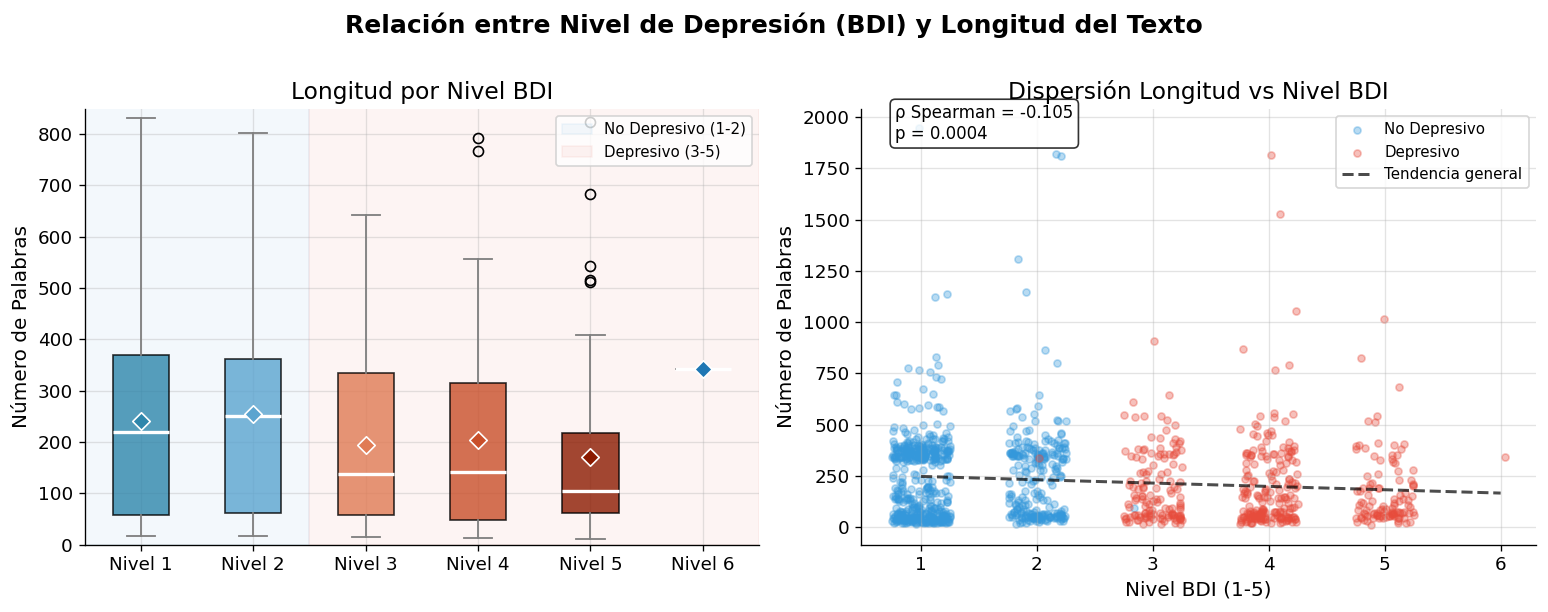


  Correlación Spearman (nivel BDI vs longitud):
  ρ = -0.1050  |  p = 0.000394


In [14]:
# ============================================================
# CELDA 7 — Correlación Nivel BDI vs Longitud del Texto
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Relación entre Nivel de Depresión (BDI) y Longitud del Texto',
             fontsize=15, fontweight='bold', y=1.01)

colores_nivel = {
    1: '#2E86AB', 2: '#5BA4CF',
    3: '#E07B54', 4: '#C94F2A', 5: '#8B1A00'
}

# 7a. Boxplot: longitud por nivel BDI
ax = axes[0]
niveles = sorted(df[COL_NIVEL].unique())
data_niveles = [df[df[COL_NIVEL] == n]['num_palabras'].values for n in niveles]
bp = ax.boxplot(data_niveles, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, nivel in zip(bp['boxes'], niveles):
    patch.set_facecolor(colores_nivel.get(nivel, '#888888'))
    patch.set_alpha(0.80)
for w in bp['whiskers']: w.set(color='gray', linewidth=1.1)
for c in bp['caps']:     c.set(color='gray', linewidth=1.1)

ax.set_xticks(range(1, len(niveles)+1))
ax.set_xticklabels([f'Nivel {n}' for n in niveles])
ax.set_ylabel('Número de Palabras')
ax.set_title('Longitud por Nivel BDI')
ax.set_ylim(0, 850)

# Anotación de clases
ax.axvspan(0.5, 2.5, alpha=0.06, color=COLOR_0, label='No Depresivo (1-2)')
ax.axvspan(2.5, len(niveles)+0.5, alpha=0.06, color=COLOR_1, label='Depresivo (3-5)')
ax.legend(fontsize=9, loc='upper right')

# Medias como puntos
for i, n in enumerate(niveles, 1):
    m = df[df[COL_NIVEL] == n]['num_palabras'].mean()
    ax.scatter(i, m, marker='D', color=colores_nivel.get(n), s=55,
               zorder=5, edgecolors='white', linewidth=1)

# 7b. Scatter: longitud vs nivel BDI con jitter
ax2 = axes[1]
jitter = np.random.uniform(-0.25, 0.25, size=len(df))
for label, color in PALETTE.items():
    mask = df[COL_LABEL] == label
    ax2.scatter(
        df.loc[mask, COL_NIVEL] + jitter[mask.values],
        df.loc[mask, 'num_palabras'],
        color=color, alpha=0.35, s=18, label=etiquetas[label]
    )
# Línea de tendencia general
z = np.polyfit(df[COL_NIVEL], df['num_palabras'], 1)
p_line = np.poly1d(z)
x_fit = np.linspace(df[COL_NIVEL].min(), df[COL_NIVEL].max(), 100)
ax2.plot(x_fit, p_line(x_fit), 'k--', linewidth=1.8, label='Tendencia general', alpha=0.7)

ax2.set_xlabel('Nivel BDI (1-5)')
ax2.set_ylabel('Número de Palabras')
ax2.set_title('Dispersión Longitud vs Nivel BDI')
ax2.set_xticks(niveles)
ax2.legend(fontsize=9)

# Correlación de Spearman
rho, p_corr = stats.spearmanr(df[COL_NIVEL], df['num_palabras'])
ax2.text(0.05, 0.93, f'ρ Spearman = {rho:.3f}\np = {p_corr:.4f}',
         transform=ax2.transAxes, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/figures/eda_bdi_vs_longitud.png', bbox_inches='tight')
plt.show()

print(f"\n  Correlación Spearman (nivel BDI vs longitud):")
print(f"  ρ = {rho:.4f}  |  p = {p_corr:.6f}")


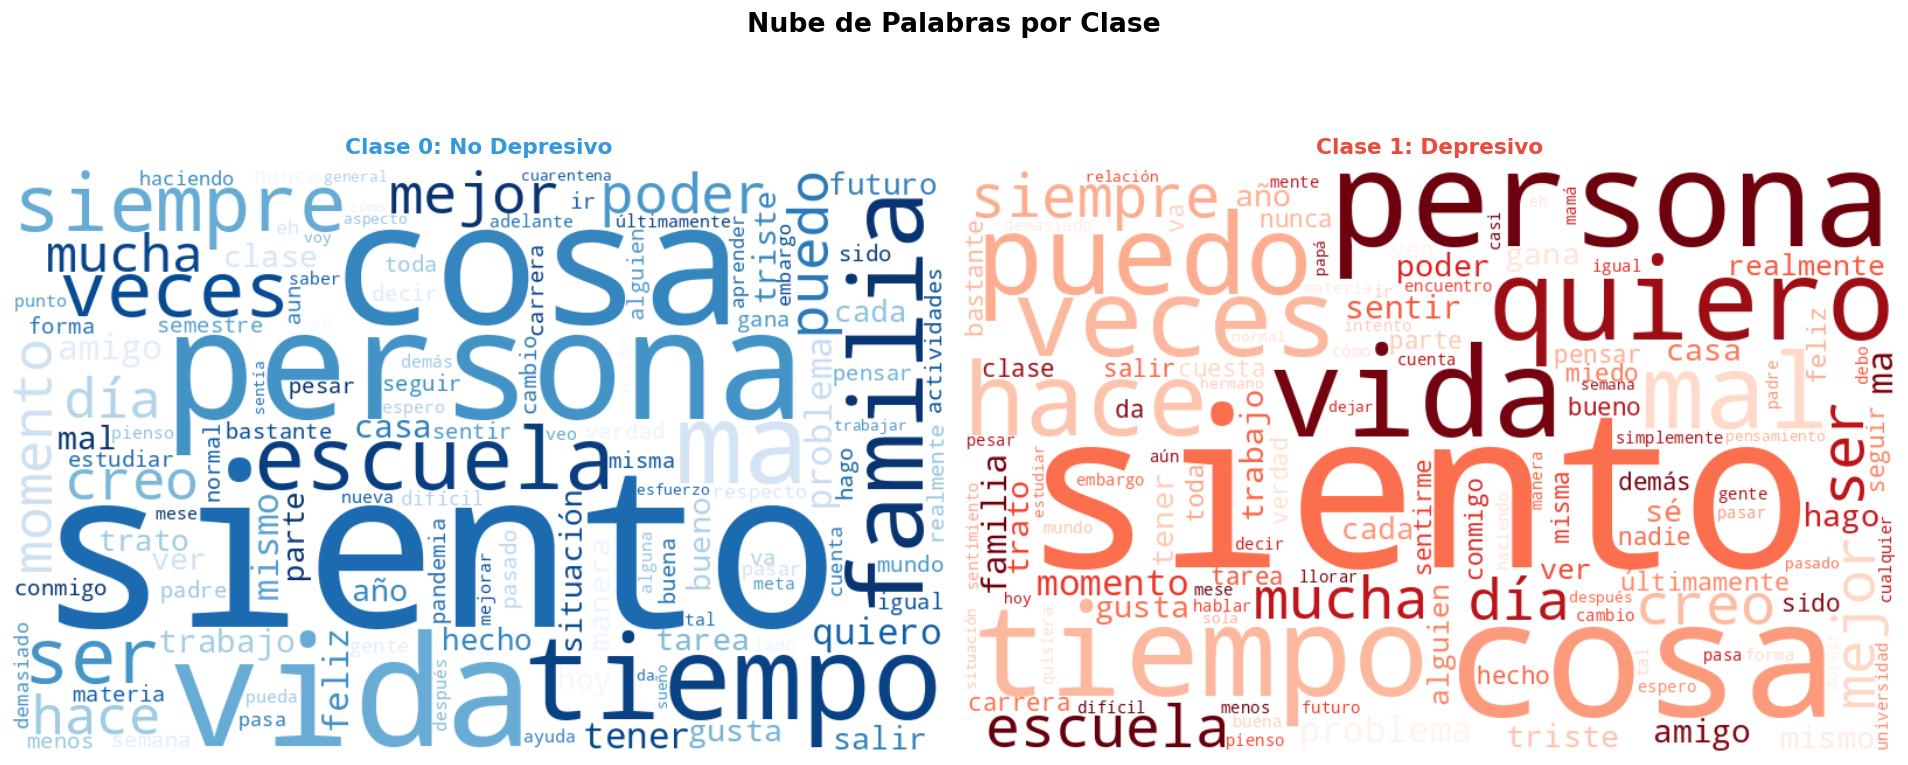

✅ Nube de palabras guardada.


In [15]:
# ============================================================
# CELDA 8 — Nube de Palabras por Clase
# ============================================================
if not WORDCLOUD_AVAILABLE:
    print("⚠️  Instala wordcloud: pip install wordcloud")
else:
    from nltk.corpus import stopwords
    import nltk
    try:
        STOPWORDS_ES = set(stopwords.words('spanish'))
    except LookupError:
        nltk.download('stopwords')
        STOPWORDS_ES = set(stopwords.words('spanish'))

    # Stopwords extra del dominio
    EXTRA_STOPS = {'así', 'si', 'aunque', 'solo', 'vez', 'tan',
                   'sino', 'pues', 'ahora', 'puede', 'hacer', 'dia',
                   'días', 'todo', 'mucho', 'nada', 'algo', 'bien'}
    STOPWORDS_ES |= EXTRA_STOPS

    def generar_texto(label):
        textos = df[df[COL_LABEL] == label][COL_TEXTO]
        return ' '.join(textos.str.lower().values)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Nube de Palabras por Clase',
                 fontsize=16, fontweight='bold', y=1.01)

    configs = [
        (0, 'No Depresivo', COLOR_0, 'Blues'),
        (1, 'Depresivo',    COLOR_1, 'Reds'),
    ]

    for ax, (label, titulo, color_bg, colormap) in zip(axes, configs):
        texto_clase = generar_texto(label)
        wc = WordCloud(
            width=800, height=500,
            background_color='white',
            stopwords=STOPWORDS_ES,
            colormap=colormap,
            max_words=120,
            collocations=False,
            prefer_horizontal=0.85,
            min_font_size=10,
        ).generate(texto_clase)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Clase {label}: {titulo}',
                     fontsize=13, fontweight='bold', color=color_bg, pad=10)

    plt.tight_layout()
    plt.savefig('../reports/figures/eda_wordcloud.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Nube de palabras guardada.")
